# P-wave-earthquake-localisation-toy-box exemple notebook

In [1]:
import numpy as np
from tqdm import tqdm

In [2]:
import generate_eq
import graphics
import commons

In [3]:
import Gauss_Newton
import Levenberg_Marquardt
import Uniq_searcher
import deepening_grid
import monte_carlo
import Evolutionary
import PSO_solver

In [4]:

# Deffine the stations, world box and V-P
#                        X       Y     Z    t
stations = np.array([[   0.0,  700.0,  0.0, 0.0],  # N°1
                     [ 700.0, 1000.0,  0.0, 0.0],  # N°2
                     [1000.0,  300.0,  0.0, 0.0],  # N°3
                     [ 500.0,  500.0, 10.0, 0.0],  # N°4
                     [ 400.0,    0.0,  0.0, 0.0]]) # N°5

box_gen = np.array([[    0.0,  1000.0],
                    [    0.0,  1000.0],
                    [-1000.0,     0.0]])

vp = 4000.0 # m/s

max_t = np.sum(np.max(box_gen**2, axis=1))**0.5 / vp

# Generate a random event without any noise
event, event_arr, stations, stations_true = generate_eq.generate_event(stations, box_gen, vp, 0.0)
print(f'Event before normalisation:\n\t{event}\n')

# Normalise the stations
stations_norm, event_norm = commons.centrering_arr(stations, event_arr)
event_norm_dict = {'X':float(event_norm[0]), 'Y':float(event_norm[1]),
                   'Z':float(event_norm[2]), 't':float(event_norm[3])}

print(f'Event after normalisation:\n\t{event_norm_dict}\n')

# Compute the normalised world box
limites = np.column_stack((np.min(stations_norm, axis=0), np.max(stations_norm, axis=0)))
limites[2, 0] = np.min(stations_norm[:, 2]) + box_gen[2, 0]
limites[3] = (-max_t, 0)

# Set the initialisation to be the same for all iterative solver
event_ini = np.random.rand(4)
event_ini = limites[:, 0] + event_ini * (limites[:, 1]-limites[:, 0])
event_ini[2] = min(event_ini[2], -1)
event_ini_dict = {'X':float(event_ini[0]), 'Y':float(event_ini[1]),
                  'Z':float(event_ini[2]), 't':float(event_ini[3])}

print(f'Initialisation:\n\t{event_ini_dict}\n')

Results = {}
Results['True event'] = {'X':float(event_norm[0]),
                         'Y':float(event_norm[1]),
                         'Z':float(event_norm[2]),
                         't':float(event_norm[3]),
                         'RMSE':0.0}


Event before normalisation:
	{'X': 324.0675706450046, 'Y': 298.86148758614905, 'Z': -986.0982071455428, 't': 1787263426.673123}

Event after normalisation:
	{'X': -175.9324293549954, 'Y': -201.13851241385095, 'Z': -996.0982071455428, 't': -0.2578299045562744}

Initialisation:
	{'X': 424.37383772208227, 'Y': -150.81828082134194, 'Z': -549.0754167473475, 't': -0.17122163306243943}



Best fitt with:
	- RMSE = 2.7595989585275905e-08
	- Event = {'X': -175.93287357550633, 'Y': -201.13872405992453, 'Z': -996.0962297565947, 't': -0.2578295002414481}


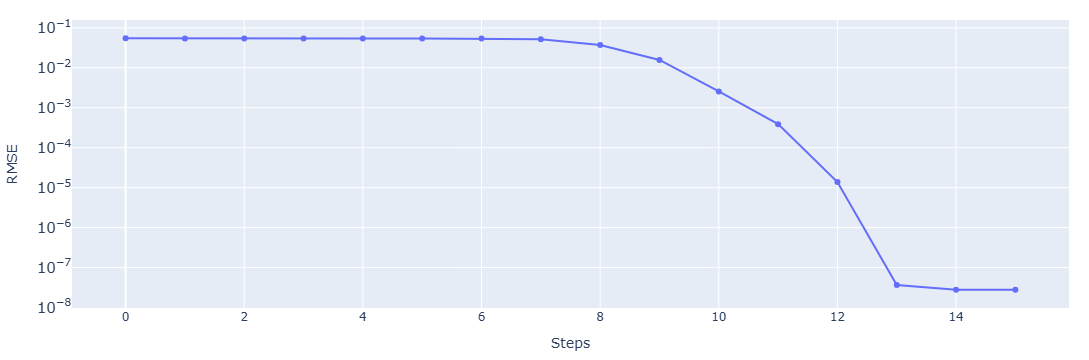

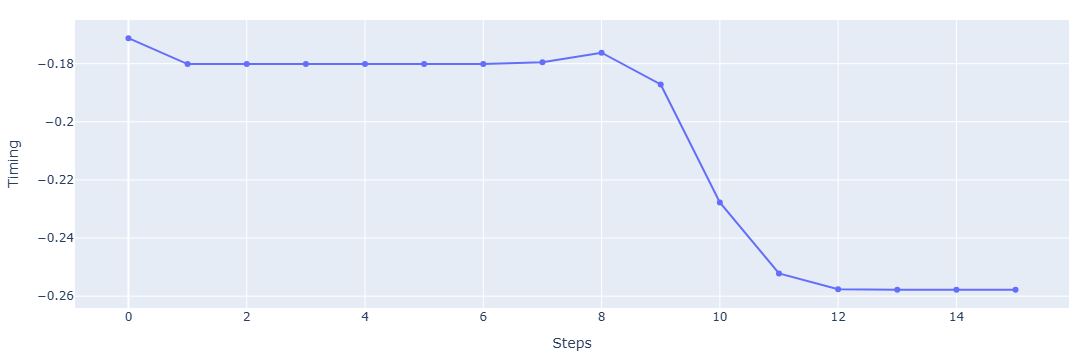

In [5]:
event_best_GN, history_GN, cost_story_GN, misfit_fin_GN = Gauss_Newton.Gauss_Newton(
    stations=stations_norm,
    event_test=np.copy(event_ini),
    n_iteration=1_000,
    steps=np.array([1.0, 1.0, 1.0, 0.0005]),
    vp=vp)

print('Best fitt with:')
print(f'\t- RMSE = {misfit_fin_GN}')
print(f'\t- Event = {event_best_GN}')

Results['Gauss-Newton'] = {'X':event_best_GN['X'],
                           'Y':event_best_GN['Y'],
                           'Z':event_best_GN['Z'],
                           't':event_best_GN['t'],
                           'RMSE':misfit_fin_GN}

_ = graphics.history_2d(cost_story_GN, 'RMSE', log_y=True, filename=None)
_ = graphics.history_2d(history_GN[:, 3], 'Timing', filename=None)
_ = graphics.history_3d(history_GN[:, :3], stations_norm, filename=None)

Best fitt with:
	- RMSE = 2.759598956182956e-08
	- Event = {'X': -175.93287357550696, 'Y': -201.13872405992518, 'Z': -996.0962297565981, 't': -0.2578295002414489}


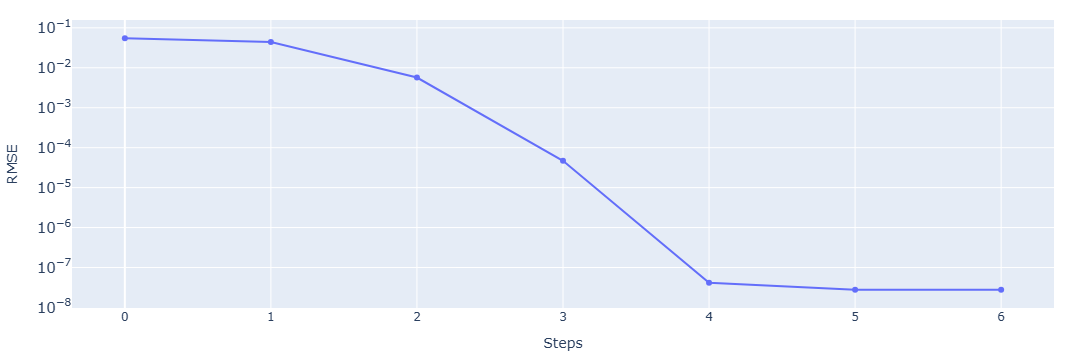

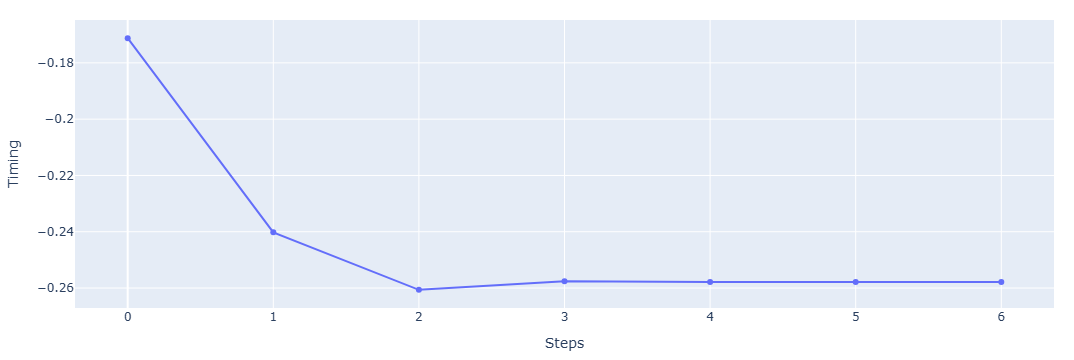

In [6]:
event_best_LM, history_LM, cost_story_LM, misfit_fin_LM = Levenberg_Marquardt.Levenberg_Marquardt(
    stations=stations_norm,
    event_test=np.copy(event_ini),
    n_iteration=1_000,
    vp=vp)

print('Best fitt with:')
print(f'\t- RMSE = {misfit_fin_LM}')
print(f'\t- Event = {event_best_LM}')

Results['Levenberg-Marquardt'] = {'X':event_best_LM['X'],
                                  'Y':event_best_LM['Y'],
                                  'Z':event_best_LM['Z'],
                                  't':event_best_LM['t'],
                                  'RMSE':misfit_fin_LM}

_ = graphics.history_2d(cost_story_LM, 'RMSE', log_y=True, filename=None)
_ = graphics.history_2d(history_LM[:, 3], 'Timing', filename=None)
_ = graphics.history_3d(history_LM[:, :3], stations_norm, filename=None)

Best fitt with:
	- RMSE = 2.7596048196594428e-08
	- Event = {'X': -175.9328743000814, 'Y': -201.13872491046175, 'Z': -996.0962347748297, 't': -0.2578295014122997}


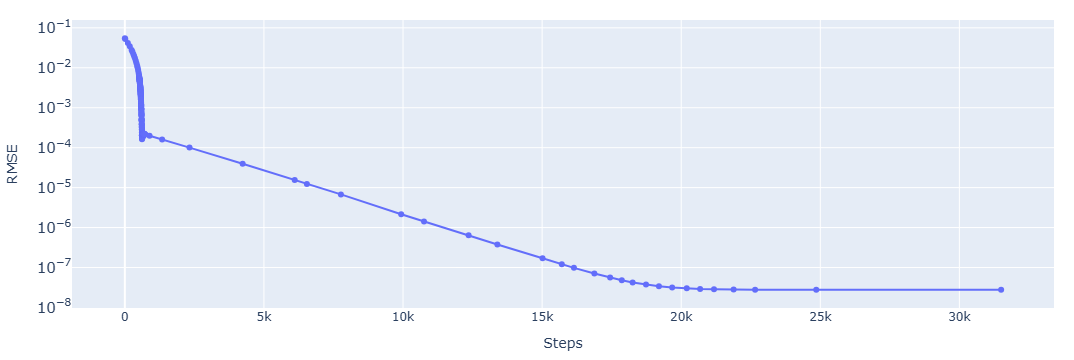

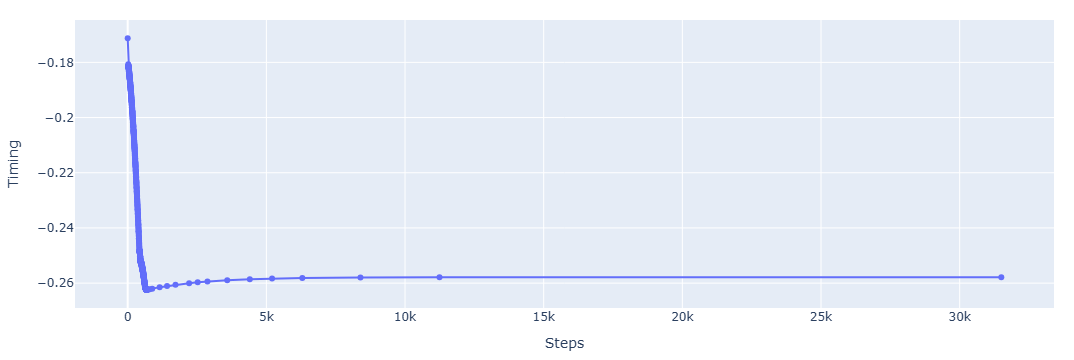

In [7]:
event_best_US, history_US, cost_story_US, misfit_fin_US = Uniq_searcher.gradient_descent(
    stations=stations_norm,
    event_test=np.copy(event_ini),
    n_iteration=200_000,
    steps=np.array([1.0, 1.0, 1.0, 0.0005]),
    lr_decay=0.05,
    patience=500,
    vp=4000.0)

print('Best fitt with:')
print(f'\t- RMSE = {misfit_fin_US}')
print(f'\t- Event = {event_best_US}')

Results['Unique searcher'] = {'X':event_best_US['X'],
                              'Y':event_best_US['Y'],
                              'Z':event_best_US['Z'],
                              't':event_best_US['t'],
                              'RMSE':misfit_fin_US}

_ = graphics.history_2d(cost_story_US, 'RMSE', log_y=True, filename=None)
_ = graphics.history_2d(history_US[:, 3], 'Timing', filename=None)
_ = graphics.history_3d(history_US[:, :3], stations_norm, filename=None)

Best fitt with:
	- RMSE = 2.7689726845848256e-08
	- Event = {'X': -175.93287658691406, 'Y': -201.1387176513672, 'Z': -996.0963134765625, 't': -0.2578295171260834}


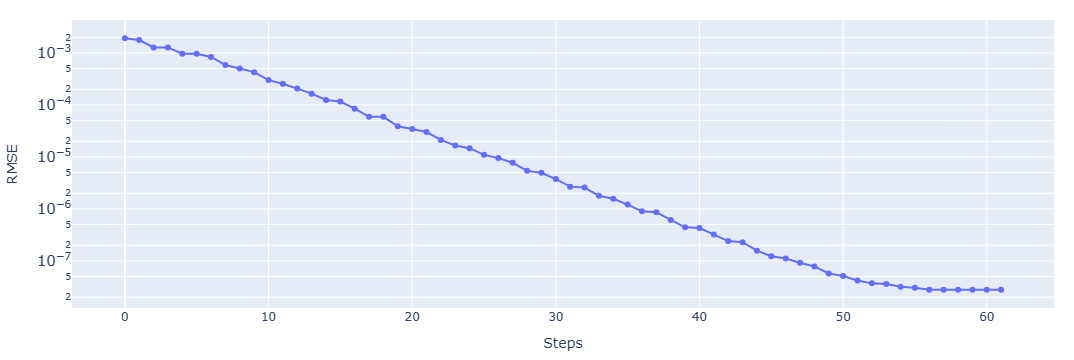

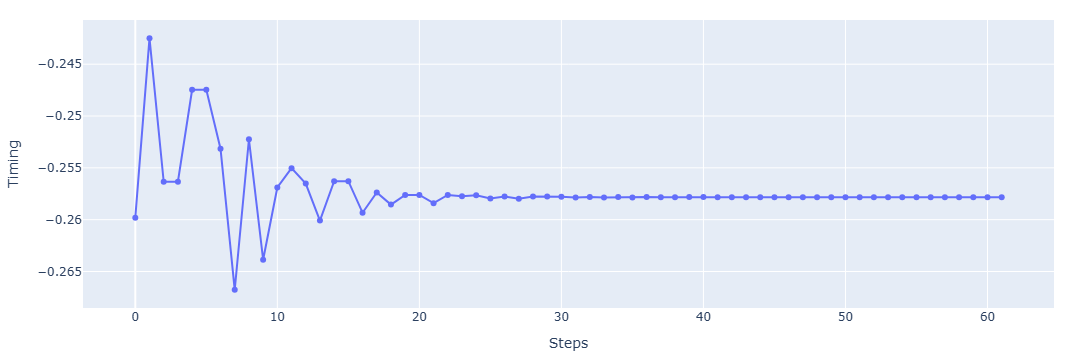

In [8]:
event_best_DG, history_DG, cost_story_DG, misfit_fin_DG = deepening_grid.deepening_grid_search(
    stations=stations_norm,
    sampling_f=21,
    limites=np.copy(limites),
    depth=10001,
    halving_rate=0.20,
    vp=4000.0)

print('Best fitt with:')
print(f'\t- RMSE = {misfit_fin_DG}')
print(f'\t- Event = {event_best_DG}')

Results['Deepening grid'] = {'X':event_best_DG['X'],
                             'Y':event_best_DG['Y'],
                             'Z':event_best_DG['Z'],
                             't':event_best_DG['t'],
                             'RMSE':misfit_fin_DG}

_ = graphics.history_2d(cost_story_DG, 'RMSE', log_y=True, filename=None)
_ = graphics.history_2d(history_DG[:, 3], 'Timing', filename=None)
_ = graphics.history_3d(history_DG[:, :3], stations_norm, filename=None)

Best fitt with:
	- RMSE = 2.808199948267733e-08
	- Event = {'X': -175.93284606933594, 'Y': -201.13877868652344, 'Z': -996.0963134765625, 't': -0.2578295171260834}


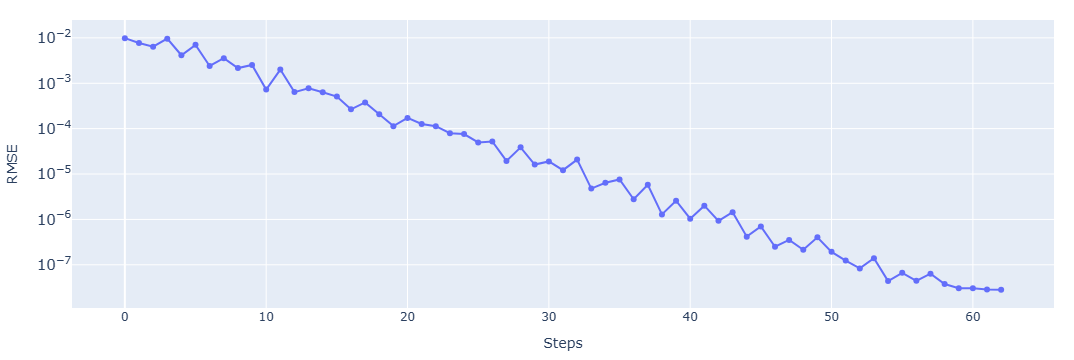

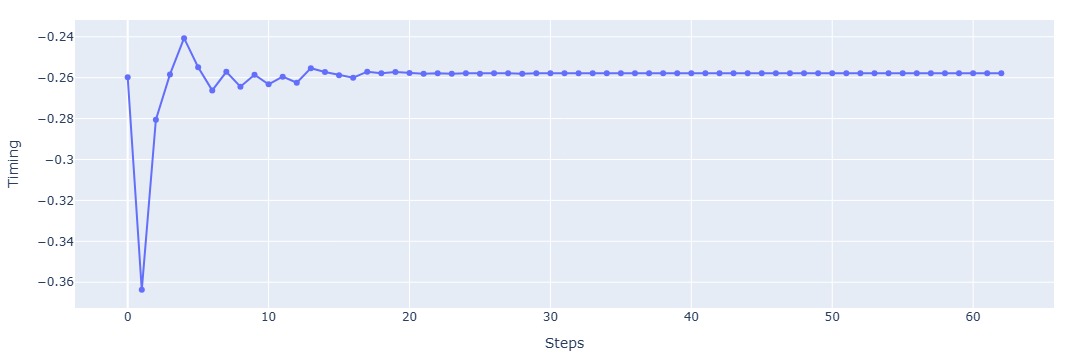

In [9]:
event_best_DS, history_DS, cost_story_DS, misfit_fin_DS = deepening_grid.deepening_grid_sampling(
    stations=stations_norm,
    sampling_f=6,
    limites=np.copy(limites),
    depth=1001,
    halving_rate=0.20,
    n_samples=100,
    vp=4000.0)

print('Best fitt with:')
print(f'\t- RMSE = {misfit_fin_DS}')
print(f'\t- Event = {event_best_DS}')

Results['Deepening sampling'] = {'X':event_best_DS['X'],
                                 'Y':event_best_DS['Y'],
                                 'Z':event_best_DS['Z'],
                                 't':event_best_DS['t'],
                                 'RMSE':misfit_fin_DS}

_ = graphics.history_2d(cost_story_DS, 'RMSE', log_y=True, filename=None)
_ = graphics.history_2d(history_DS[:, 3], 'Timing', filename=None)
_ = graphics.history_3d(history_DS[:, :3], stations_norm, filename=None)

Best fitt with:
	- RMSE = 0.0009963038610294461
	- Event = {'X': -160.09503173828125, 'Y': -188.37681579589844, 'Z': -963.1604614257812, 't': -0.24952904880046844}


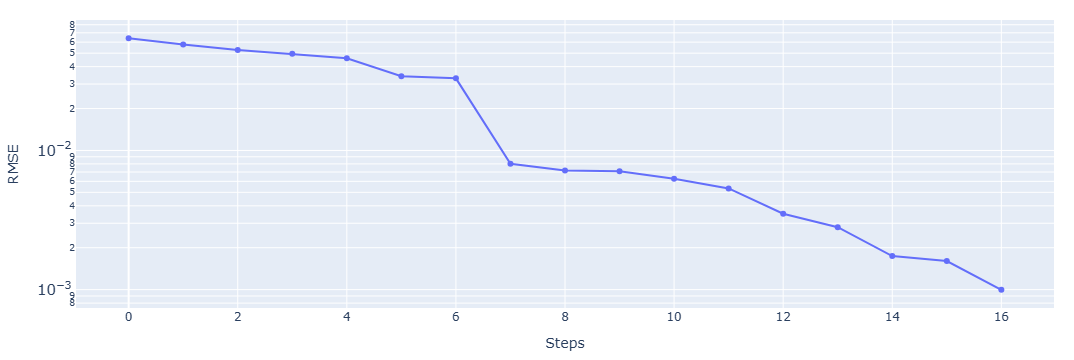

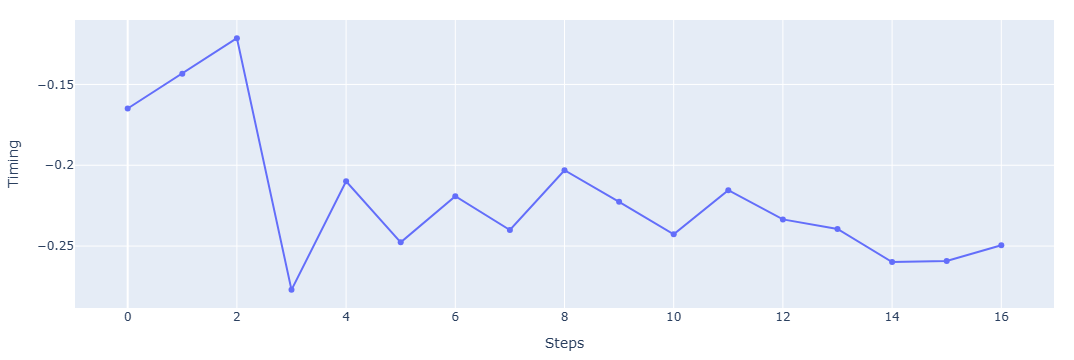

In [10]:
event_best_Mu, history_Mu, cost_story_Mu, misfit_fin_Mu = monte_carlo.monte_carlo(
    stations=stations_norm,
    limites=np.copy(limites),
    n_samples=10_000_000,
    sampling='uniform',
    vp=4000.0)

print('Best fitt with:')
print(f'\t- RMSE = {misfit_fin_Mu}')
print(f'\t- Event = {event_best_Mu}')

Results['Monte-Carlo uniform'] = {'X':event_best_Mu['X'],
                                  'Y':event_best_Mu['Y'],
                                  'Z':event_best_Mu['Z'],
                                  't':event_best_Mu['t'],
                                  'RMSE':misfit_fin_Mu}

_ = graphics.history_2d(cost_story_Mu, 'RMSE', log_y=True, filename=None)
_ = graphics.history_2d(history_Mu[:, 3], 'Timing', filename=None)
_ = graphics.history_3d(history_Mu[:, :3], stations_norm, filename=None)

Best fitt with:
	- RMSE = 0.0010643203277140856
	- Event = {'X': -189.99684143066406, 'Y': -197.81182861328125, 'Z': -1010.0, 't': -0.26098567247390747}


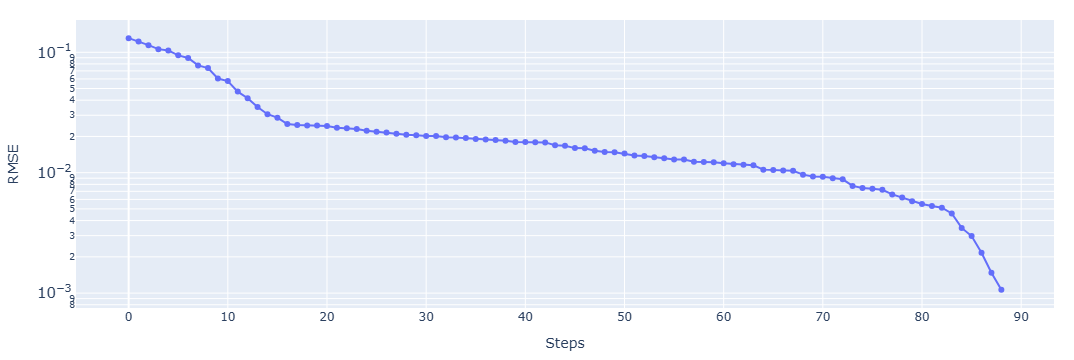

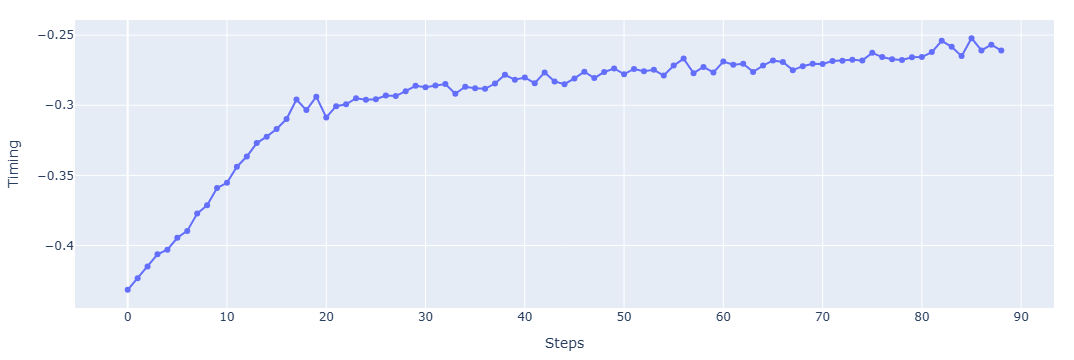

In [11]:
event_best_Mg, history_Mg, cost_story_Mg, misfit_fin_Mg = monte_carlo.monte_carlo(
    stations=stations_norm,
    limites=np.copy(limites),
    n_samples=10_000_000,
    sampling='grid_rand',
    vp=4000.0)

print('Best fitt with:')
print(f'\t- RMSE = {misfit_fin_Mg}')
print(f'\t- Event = {event_best_Mg}')

Results['Monte-Carlo r grid'] = {'X':event_best_Mg['X'],
                                 'Y':event_best_Mg['Y'],
                                 'Z':event_best_Mg['Z'],
                                 't':event_best_Mg['t'],
                                 'RMSE':misfit_fin_Mg}

_ = graphics.history_2d(cost_story_Mg, 'RMSE', log_y=True, filename=None)
_ = graphics.history_2d(history_Mg[:, 3], 'Timing', filename=None)
_ = graphics.history_3d(history_Mg[:, :3], stations_norm, filename=None)

Best fitt with:
	- RMSE = 0.0008787438273429871
	- Event = {'X': -168.88568115234375, 'Y': -189.7316131591797, 'Z': -987.3753662109375, 't': -0.2555476725101471}


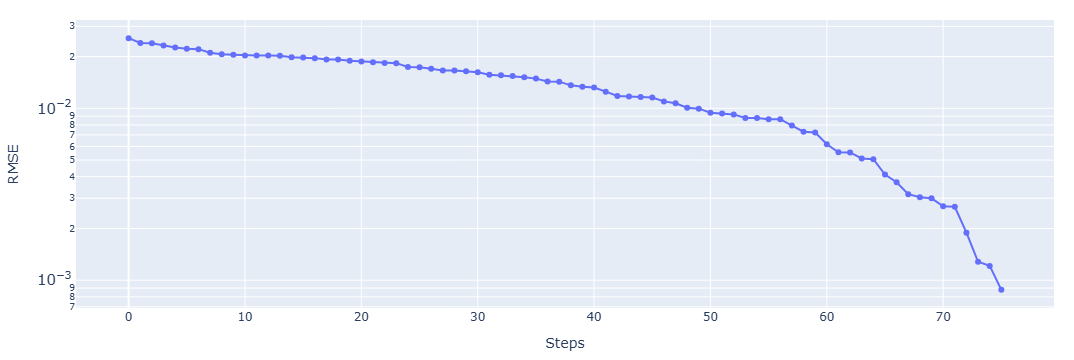

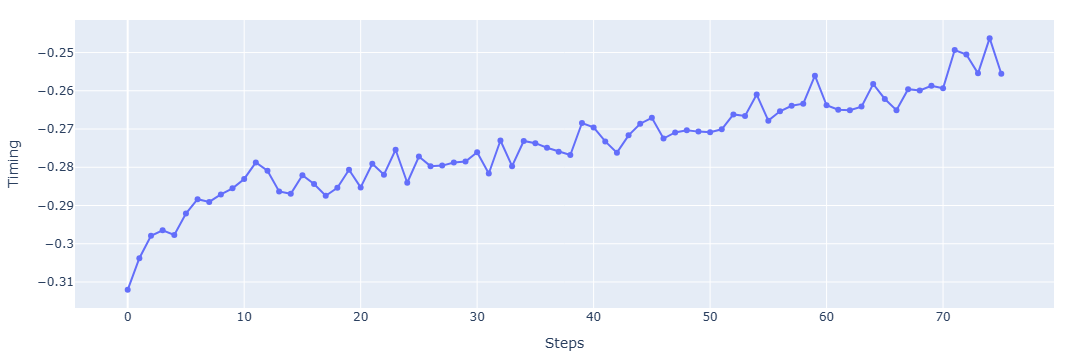

In [12]:
event_best_Mf, history_Mf, cost_story_Mf, misfit_fin_Mf = monte_carlo.monte_carlo(
    stations=stations_norm,
    limites=np.copy(limites),
    n_samples=10_000_000,
    sampling='fcc',
    vp=4000.0)

print('Best fitt with:')
print(f'\t- RMSE = {misfit_fin_Mf}')
print(f'\t- Event = {event_best_Mf}')

Results['Monte-Carlo fcc sampling'] = {'X':event_best_Mf['X'],
                                       'Y':event_best_Mf['Y'],
                                       'Z':event_best_Mf['Z'],
                                       't':event_best_Mf['t'],
                                       'RMSE':misfit_fin_Mf}

_ = graphics.history_2d(cost_story_Mf, 'RMSE', log_y=True, filename=None)
_ = graphics.history_2d(history_Mf[:, 3], 'Timing', filename=None)
_ = graphics.history_3d(history_Mf[:, :3], stations_norm, filename=None)

Best fitt with:
	- RMSE = 2.7595990167063066e-08
	- Event = {'X': -175.9328735764582, 'Y': -201.1387241158902, 'Z': -996.0962299187864, 't': -0.2578295002840628}


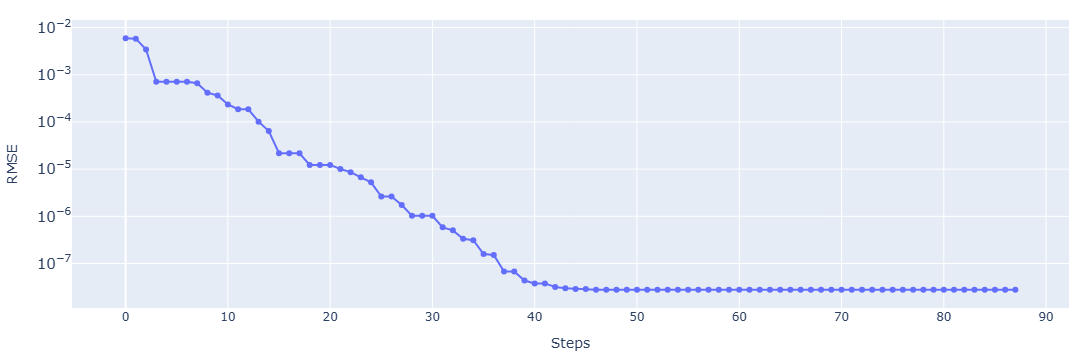

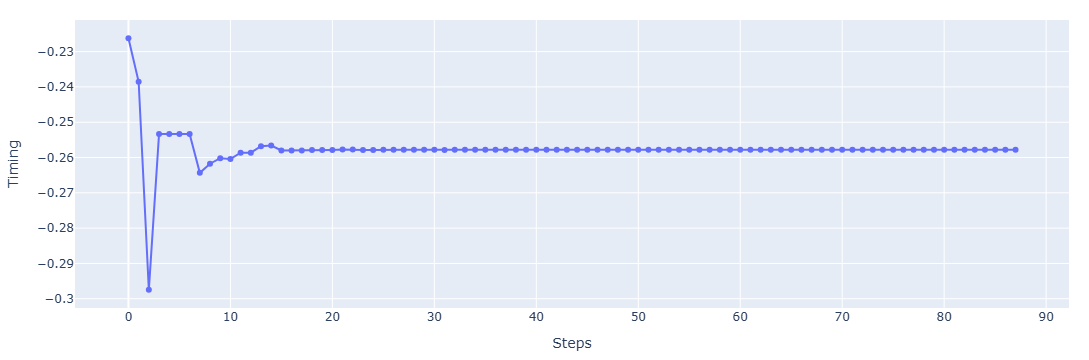

In [13]:
event_best_EV, history_EV, cost_story_EV, misfit_fin_EV = Evolutionary.evolution(
    pop_size=10_000,
    limites=np.copy(limites),
    n_iteration=1_000,
    stations=stations_norm,
    p_surv=0.10,
    patience=10,
    vp=4000.0)

print('Best fitt with:')
print(f'\t- RMSE = {misfit_fin_EV}')
print(f'\t- Event = {event_best_EV}')

Results['Evolutionary'] = {'X':event_best_EV['X'],
                           'Y':event_best_EV['Y'],
                           'Z':event_best_EV['Z'],
                           't':event_best_EV['t'],
                           'RMSE':misfit_fin_EV}

_ = graphics.history_2d(cost_story_EV, 'RMSE', log_y=True, filename=None)
_ = graphics.history_2d(history_EV[:, 3], 'Timing', filename=None)
_ = graphics.history_3d(history_EV[:, :3], stations_norm, filename=None)

Best fitt with:
	- RMSE = 2.7595989700409226e-08
	- Event = {'X': -175.93287352828236, 'Y': -201.13872402611307, 'Z': -996.0962295808567, 't': -0.2578295001994392}


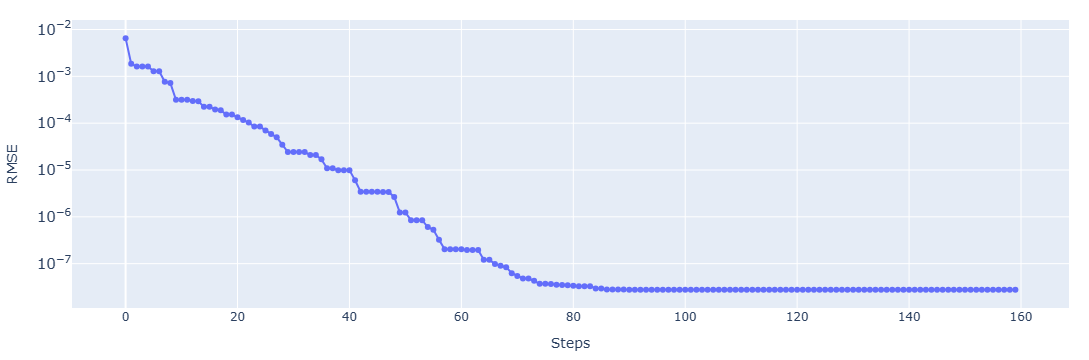

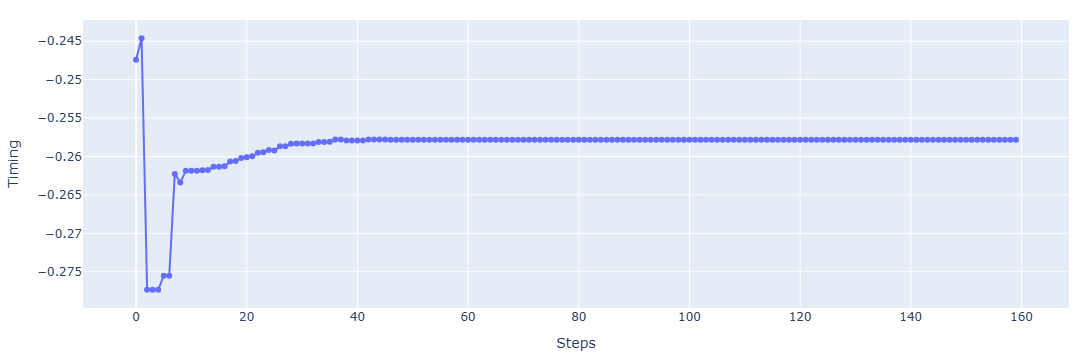

In [14]:
event_best_PSO, history_PSO, cost_story_PSO, misfit_fin_PSO = PSO_solver.evolution(
    stations=stations_norm,
    limites=np.copy(limites),
    n_iteration=1_000,
    pop_size=1_000,
    inertia=0.5,
    c_cogni=1.5,
    c_social=1.5,
    patience=15,
    vp=4000.0)

print('Best fitt with:')
print(f'\t- RMSE = {misfit_fin_PSO}')
print(f'\t- Event = {event_best_PSO}')

Results['PSO Solver'] = {'X':event_best_PSO['X'],
                         'Y':event_best_PSO['Y'],
                         'Z':event_best_PSO['Z'],
                         't':event_best_PSO['t'],
                         'RMSE':misfit_fin_PSO}

_ = graphics.history_2d(cost_story_PSO, 'RMSE', log_y=True, filename=None)
_ = graphics.history_2d(history_PSO[:, 3], 'Timing', filename=None)
_ = graphics.history_3d(history_PSO[:, :3], stations_norm, filename=None)

In [15]:
# Making some comparison
_ = graphics.solver_compare(Results,
                            None,
                            None,
                            title="Solver Comparison",
                            colorscale="Viridis",
                            filename=None,
                            height=1000)

In [16]:
_ = graphics.build_tables(Results, rounding=9)

+--------------------------+----------------+----------------+----------------+--------------+---------------+
|          Models          |       X        |       Y        |       Z        |      t       | RMSE (*10^-3) |
+--------------------------+----------------+----------------+----------------+--------------+---------------+
|        True event        | -175.932429355 | -201.138512414 | -996.098207146 | -0.257829905 |      0.0      |
+--------------------------+----------------+----------------+----------------+--------------+---------------+
|   Levenberg-Marquardt    | -175.932873576 | -201.13872406  | -996.096229757 |  -0.2578295  |    2.8e-05    |
+--------------------------+----------------+----------------+----------------+--------------+---------------+
|       Gauss-Newton       | -175.932873576 | -201.13872406  | -996.096229757 |  -0.2578295  |    2.8e-05    |
+--------------------------+----------------+----------------+----------------+--------------+---------------+
|

In [17]:

num_test = 200

compilations = {key:np.zeros((num_test, 3)) for key in Results}
compilations.pop('True event')

for i in tqdm(range(num_test)):
    # Generate a random event without any noise
    event, event_arr, stations, stations_true = generate_eq.generate_event(stations, box_gen, vp, 0.0)

    # Normalise the stations
    stations_norm, event_norm = commons.centrering_arr(stations, event_arr)
    event_norm_dict = {'X':float(event_norm[0]), 'Y':float(event_norm[1]),
                       'Z':float(event_norm[2]), 't':float(event_norm[3])}

    # Set the initialisation to be the same for all iterative solver
    event_ini = np.random.rand(4)
    event_ini = limites[:, 0] + event_ini * (limites[:, 1]-limites[:, 0])
    event_ini[2] = min(event_ini[2], -1)
    event_ini_dict = {'X':float(event_ini[0]), 'Y':float(event_ini[1]),
                      'Z':float(event_ini[2]), 't':float(event_ini[3])}

    best_GN, hist_GN, costs_GN, misfit_GN = Gauss_Newton.Gauss_Newton(stations=stations_norm,
                                                                      event_test=np.copy(event_ini),
                                                                      n_iteration=1_000,
                                                                      steps=np.array([1.0, 1.0, 1.0, 0.0005]),
                                                                      vp=vp)
    compilations['Gauss-Newton'][i, 0] = commons.distance_dict2dict(best_GN, event_norm_dict)
    compilations['Gauss-Newton'][i, 1] = misfit_GN

    best_LM, hist_LM, costs_LM, misfit_LM = Levenberg_Marquardt.Levenberg_Marquardt(stations=stations_norm,
                                                                                    event_test=np.copy(event_ini),
                                                                                    n_iteration=1_000,
                                                                                    vp=vp)
    compilations['Levenberg-Marquardt'][i, 0] = commons.distance_dict2dict(best_LM, event_norm_dict)
    compilations['Levenberg-Marquardt'][i, 1] = misfit_LM

    best_US, hist_US, costs_US, misfit_US = Uniq_searcher.gradient_descent(stations=stations_norm,
                                                                           event_test=np.copy(event_ini),
                                                                           n_iteration=200_000,
                                                                           steps=np.array([1.0, 1.0, 1.0, 0.0005]),
                                                                           lr_decay=0.05,
                                                                           patience=500,
                                                                           vp=4000.0)
    compilations['Unique searcher'][i, 0] = commons.distance_dict2dict(best_US, event_norm_dict)
    compilations['Unique searcher'][i, 1] = misfit_US

    best_DG, hist_DG, costs_DG, misfit_DG = deepening_grid.deepening_grid_search(stations=stations_norm,
                                                                                 sampling_f=21,
                                                                                 limites=np.copy(limites),
                                                                                 depth=10001,
                                                                                 halving_rate=0.20,
                                                                                 vp=4000.0)
    compilations['Deepening grid'][i, 0] = commons.distance_dict2dict(best_DG, event_norm_dict)
    compilations['Deepening grid'][i, 1] = misfit_DG

    best_DS, hist_DS, costs_DS, misfit_DS = deepening_grid.deepening_grid_sampling(stations=stations_norm,
                                                                                   sampling_f=6,
                                                                                   limites=np.copy(limites),
                                                                                   depth=1001,
                                                                                   halving_rate=0.20,
                                                                                   n_samples=100,
                                                                                   vp=4000.0)
    compilations['Deepening sampling'][i, 0] = commons.distance_dict2dict(best_DS, event_norm_dict)
    compilations['Deepening sampling'][i, 1] = misfit_DS

    best_Mu, hist_Mu, costs_Mu, misfit_Mu = monte_carlo.monte_carlo(stations=stations_norm,
                                                                    limites=np.copy(limites),
                                                                    n_samples=10_000_000,
                                                                    sampling='uniform',
                                                                    vp=4000.0)
    compilations['Monte-Carlo uniform'][i, 0] = commons.distance_dict2dict(best_Mu, event_norm_dict)
    compilations['Monte-Carlo uniform'][i, 1] = misfit_Mu

    best_Mg, hist_Mg, costs_Mg, misfit_Mg = monte_carlo.monte_carlo(stations=stations_norm,
                                                                    limites=np.copy(limites),
                                                                    n_samples=10_000_000,
                                                                    sampling='grid_rand',
                                                                    vp=4000.0)
    compilations['Monte-Carlo r grid'][i, 0] = commons.distance_dict2dict(best_Mg, event_norm_dict)
    compilations['Monte-Carlo r grid'][i, 1] = misfit_Mg

    best_Mf, hist_Mf, costs_Mf, misfit_Mf = monte_carlo.monte_carlo(stations=stations_norm,
                                                                    limites=np.copy(limites),
                                                                    n_samples=10_000_000,
                                                                    sampling='fcc',
                                                                    vp=4000.0)
    compilations['Monte-Carlo fcc sampling'][i, 0] = commons.distance_dict2dict(best_Mf, event_norm_dict)
    compilations['Monte-Carlo fcc sampling'][i, 1] = misfit_Mf

    best_EV, hist_EV, costs_EV, misfit_EV = Evolutionary.evolution(pop_size=10_000,
                                                                   limites=np.copy(limites),
                                                                   n_iteration=1_000,
                                                                   stations=stations_norm,
                                                                   p_surv=0.10,
                                                                   patience=10,
                                                                   vp=4000.0)
    compilations['Evolutionary'][i, 0] = commons.distance_dict2dict(best_EV, event_norm_dict)
    compilations['Evolutionary'][i, 1] = misfit_EV

    best_PSO, hist_PSO, costs_PSO, misfit_PSO = PSO_solver.evolution(stations=stations_norm,
                                                                     limites=np.copy(limites),
                                                                     n_iteration=1_000,
                                                                     pop_size=1_000,
                                                                     inertia=0.5,
                                                                     c_cogni=1.5,
                                                                     c_social=1.5,
                                                                     patience=15,
                                                                     vp=4000.0)
    compilations['PSO Solver'][i, 0] = commons.distance_dict2dict(best_PSO, event_norm_dict)
    compilations['PSO Solver'][i, 1] = misfit_PSO


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [11:32<00:00,  3.46s/it]


In [18]:
Compiled_table = {'Distance':{key:{} for key in compilations},
                  'RMSE':    {key:{} for key in compilations}}

quantiles = np.array(['0.00', '0.25', '0.50', '0.75', '1.00'])
for key in compilations:
    for q in quantiles:
        cle = f'Q {round(float(q)*100)}%'
        Compiled_table['Distance'][key][cle] = np.quantile(compilations[key][:, 0], float(q))
        Compiled_table['RMSE'][key][cle] = np.quantile(compilations[key][:, 1], float(q))

    Compiled_table['Distance'][key]['Deviation'] = np.std(compilations[key][:, 0])
    Compiled_table['RMSE'][key]['Deviation'] = np.std(compilations[key][:, 1])

    Compiled_table['Distance'][key]['Average'] = np.mean(compilations[key][:, 0])
    Compiled_table['RMSE'][key]['Average'] = np.mean(compilations[key][:, 1])


In [19]:
_ = graphics.build_tables(Compiled_table['Distance'], rounding=9)

+--------------------------+-------------+--------------+--------------+--------------+----------------+---------------+-----------------+
|          Models          |    Q 0%     |    Q 25%     |    Q 50%     |    Q 75%     |     Q 100%     |   Deviation   | Average (*10^0) |
+--------------------------+-------------+--------------+--------------+--------------+----------------+---------------+-----------------+
|       Evolutionary       | 8.5777e-05  | 0.000728089  | 0.001233997  | 0.002281372  |  0.007688892   |  0.001374087  |   0.001701307   |
+--------------------------+-------------+--------------+--------------+--------------+----------------+---------------+-----------------+
|      Deepening grid      | 6.6161e-05  | 0.000750899  | 0.001227113  | 0.002264843  |  0.008440363   |  0.001383206  |   0.001701852   |
+--------------------------+-------------+--------------+--------------+--------------+----------------+---------------+-----------------+
|   Levenberg-Marquardt    

In [20]:
_ = graphics.build_tables(Compiled_table['RMSE'], rounding=9)

+--------------------------+-------------+-------------+-------------+-------------+-------------+-------------+------------------+
|          Models          |    Q 0%     |    Q 25%    |    Q 50%    |    Q 75%    |   Q 100%    |  Deviation  | Average (*10^-3) |
+--------------------------+-------------+-------------+-------------+-------------+-------------+-------------+------------------+
|   Levenberg-Marquardt    |     0.0     |    9e-09    |   2.2e-08   |   3.5e-08   |   7.8e-08   |   1.7e-08   |     2.4e-05      |
+--------------------------+-------------+-------------+-------------+-------------+-------------+-------------+------------------+
|     Unique searcher      |    2e-09    |    1e-08    |   2.2e-08   |   3.5e-08   |   7.8e-08   |   1.7e-08   |     2.5e-05      |
+--------------------------+-------------+-------------+-------------+-------------+-------------+-------------+------------------+
|       Evolutionary       |    4e-09    |    1e-08    |   2.2e-08   |   3.5